# Dispersal vs Ecology Metrics v10


Plots based on ASV-level spatiotemporal anomaly, in the gyre only (site 16 or later).

Key data was produced in `lat_diel_running_means_v3.ipynb`: highcov_dir + `phyto_ASV_spatiotemporal_group_anoms_v3.csv`


Jones-Kellett et al. figs in this script:
1. Fig. 4 : Euk phyto STA vs. coherence
2. Fig. 5 : Euk major group STA vs. coherence, exponential decay fit
3. Fig. S8 : Cyano STA vs. coherence 
4. Fig. S9 : Euk group STA vs. coherence

Other things in paper from this script:
- Table S3 : Phytoplankton group statistics

NOTES

v10: Cleaning up script for publication

v9: Improved lat anom / temporal fit on non-zero data is used

v8: Redefining "near eddy" as <15km from eddy boundary (previously was <25km)
- Boundary work was done on the cluster

----


Lexi Jones-Kellett

Date created: 03/03/26

Last edited: 03/03/26

In [1]:
import csv,math,statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as spy
#from sklearn.metrics import r2_score #currently not installed on home computer
from scipy.signal import argrelextrema
from scipy.optimize import curve_fit
from decimal import Decimal
from matplotlib.patches import CirclePolygon
from matplotlib.lines import Line2D
from config import * # directory file paths

In [2]:
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

Create scatter plots with eddy & latitude information

In [3]:
metadata_df = pd.read_csv(data_dir + 'AVISO_metadata_15km_near_eddy.csv',index_col=0)
metadata_df = metadata_df.set_index('sample_id')
metadata_df

,date,time_UTC,latitude,longitude,in_anti,near_anti,in_cyc,near_cyc
sample_id,,,,,,,,
3,20211119,11:04,31.8350,241.3917,0,0,838480,0
4,20211119,13:10,31.5750,240.9592,0,0,838480,0
5,20211119,15:19,31.3125,240.4938,0,799642,0,0
6,20211119,17:11,31.0850,240.1052,799642,0,0,0
7,20211119,19:04,30.8575,239.7167,0,0,0,0
...,...,...,...,...,...,...,...,...
67,20211126,20:58,17.2820,219.9525,0,0,845344,0
68,20211126,23:04,16.8736,219.9950,0,0,0,845344
69,20211127,01:02,16.4513,219.9996,0,0,0,0


Add column for eddy age

In [4]:
anti_df = pd.read_csv(data_dir + 'AVISO_anti_eddy_G4_crossing_data.csv')
anti_df

,Date,Eddy ID,Age (days),Age (frac of life),Speed (m/s),Center Lon,Center Lat,Contour Lons,Contour Lats
0,20211119,799642,10,0.108696,0.1355,240.109833,31.375994,"[239.88, 240.12, 240.13, 240.38, 240.39, 240.4...","[30.89, 30.91, 30.91, 31.09, 31.13, 31.369999,..."
1,20211123,799833,12,0.214286,0.1076,225.904083,22.250608,"[225.38, 225.62, 226.1, 226.37, 226.62, 226.95...","[21.57, 21.539999, 21.63, 21.74, 21.77, 21.88,..."


In [5]:
cyc_df = pd.read_csv(data_dir + 'AVISO_cyc_eddy_G4_crossing_data.csv')
cyc_df

,Date,Eddy ID,Age (days),Age (frac of life),Speed (m/s),Center Lon,Center Lat,Contour Lons,Contour Lats
0,20211119,838480,131,0.873333,0.1804,241.245865,31.479284,"[241.12, 240.98999, 240.95, 240.88, 240.8, 240...","[30.609999, 30.88, 31.13, 31.34, 31.619999, 31..."
1,20211119,846424,33,0.286957,0.2098,238.738678,31.000278,"[238.38, 238.13, 238.03, 238.06, 238.20999, 23...","[30.09, 30.21, 30.369999, 30.619999, 30.869999..."
2,20211120,846424,34,0.295652,0.2080,238.717041,31.008432,"[238.38, 238.12, 238.0, 238.06, 238.23999, 238...","[30.08, 30.189999, 30.38, 30.619999, 30.869999..."
3,20211121,849094,1,0.038462,0.0449,234.287827,27.966232,"[234.12, 233.97, 233.88, 233.87, 233.86, 233.8...","[27.67, 27.88, 28.0, 28.019999, 28.119999, 28...."
4,20211121,831329,224,0.736842,0.1646,232.931168,26.213045,"[232.88, 232.63, 232.20999, 232.05, 231.93, 23...","[25.369999, 25.519999, 25.869999, 26.13, 26.61..."
5,20211122,831329,225,0.740132,0.1693,232.911194,26.217823,"[232.88, 232.63, 232.19, 232.02, 231.9, 231.98...","[25.369999, 25.51, 25.88, 26.14, 26.63, 26.88,..."
6,20211122,844202,63,0.443662,0.0716,228.087341,23.910452,"[227.88, 227.65, 227.64, 227.65, 227.63, 227.6...","[23.279999, 23.369999, 23.39, 23.619999, 23.86..."
7,20211123,823188,326,0.806931,0.1998,223.682907,20.675846,"[222.51, 222.51, 222.62, 222.73999, 222.92, 22...","[19.619999, 19.869999, 20.619999, 20.88, 21.13..."
8,20211124,823188,327,0.809406,0.2029,223.662094,20.700729,"[222.45, 222.54001, 222.53, 222.57, 223.13, 22...","[19.63, 20.119999, 20.369999, 20.619999, 21.66..."
9,20211124,847844,20,0.210526,0.1055,221.653381,19.704439,"[221.62, 221.41, 221.37, 221.19, 221.15, 221.1...","[19.3, 19.369999, 19.41, 19.619999, 19.869999,..."


In [6]:
eddy_age_days = []
eddy_age_frac = []

for index, row in metadata_df.iterrows():    
    if row.in_cyc != 0:
        ind = np.where((cyc_df['Date'] == row.date) & (cyc_df['Eddy ID'] == row.in_cyc))[0][0]
        eddy_age_days.append(cyc_df.iloc[ind]['Age (days)'])
        eddy_age_frac.append(cyc_df.iloc[ind]['Age (frac of life)'])
        
    elif row.near_cyc != 0:
        ind = np.where((cyc_df['Date'] == row.date) & (cyc_df['Eddy ID'] == row.near_cyc))[0][0]
        eddy_age_days.append(cyc_df.iloc[ind]['Age (days)'])
        eddy_age_frac.append(cyc_df.iloc[ind]['Age (frac of life)'])
        
    elif row.in_anti != 0:
        ind = np.where((anti_df['Date'] == row.date) & (anti_df['Eddy ID'] == row.in_anti))[0][0]
        eddy_age_days.append(anti_df.iloc[ind]['Age (days)'])
        eddy_age_frac.append(anti_df.iloc[ind]['Age (frac of life)'])
        
    elif row.near_anti != 0:
        ind = np.where((anti_df['Date'] == row.date) & (anti_df['Eddy ID'] == row.near_anti))[0][0]
        eddy_age_days.append(anti_df.iloc[ind]['Age (days)'])
        eddy_age_frac.append(anti_df.iloc[ind]['Age (frac of life)'])
    else:
        eddy_age_days.append(np.nan)
        eddy_age_frac.append(np.nan)

In [7]:
metadata_df['eddy_age_days'] = eddy_age_days
metadata_df['eddy_age_frac'] = eddy_age_frac
metadata_df.head()

,date,time_UTC,latitude,longitude,in_anti,near_anti,in_cyc,near_cyc,eddy_age_days,eddy_age_frac
sample_id,,,,,,,,,,
3,20211119,11:04,31.8350,241.3917,0,0,838480,0,131.0,0.873333
4,20211119,13:10,31.5750,240.9592,0,0,838480,0,131.0,0.873333
5,20211119,15:19,31.3125,240.4938,0,799642,0,0,10.0,0.108696
6,20211119,17:11,31.0850,240.1052,799642,0,0,0,10.0,0.108696
7,20211119,19:04,30.8575,239.7167,0,0,0,0,NaN,NaN


In [8]:
print(max(metadata_df['eddy_age_days']))
print(min(metadata_df['eddy_age_days']))

print(max(metadata_df['eddy_age_frac']))
print(min(metadata_df['eddy_age_frac']))

327.0
1.0
0.8733333333333333
0.0384615384615384


Add a column for eddy color to df for plotting

In [9]:
eddy_color = []
for s in metadata_df.index:
    if int(metadata_df.loc[s]['in_cyc']) != 0: 
        eddy_color.append('mediumblue')
    elif int(metadata_df.loc[s]['near_cyc']) != 0: 
        eddy_color.append('cornflowerblue')
    elif int(metadata_df.loc[s]['in_anti']) != 0: 
        eddy_color.append('firebrick')
    elif int(metadata_df.loc[s]['near_anti']) != 0: 
        eddy_color.append('lightcoral')
    else:
        eddy_color.append('k')

In [10]:
metadata_df['eddy_color'] = eddy_color
metadata_df.head()

,date,time_UTC,latitude,longitude,in_anti,near_anti,in_cyc,near_cyc,eddy_age_days,eddy_age_frac,eddy_color
sample_id,,,,,,,,,,,
3,20211119,11:04,31.8350,241.3917,0,0,838480,0,131.0,0.873333,mediumblue
4,20211119,13:10,31.5750,240.9592,0,0,838480,0,131.0,0.873333,mediumblue
5,20211119,15:19,31.3125,240.4938,0,799642,0,0,10.0,0.108696,lightcoral
6,20211119,17:11,31.0850,240.1052,799642,0,0,0,10.0,0.108696,firebrick
7,20211119,19:04,30.8575,239.7167,0,0,0,0,NaN,NaN,k


In [11]:
coh_df = pd.read_csv(data_dir + 'coh_days_200day_backward_runtime_20min_timestep_6hr_output_freq_1000_gaussian_particles_0.025_std_dist_CMEMS_OSCAR_interim.csv',header=1,index_col='sample_id')
coh_df = coh_df.reset_index()
coh_df = coh_df.drop('0',axis='columns')
coh_df.head()

,sample_id,CMEMS_coherence_days_run0,CMEMS_coherence_days_run1,CMEMS_coherence_days_run2,OSCAR_coherence_days_run0,OSCAR_coherence_days_run1,OSCAR_coherence_days_run2
0,3,21.50,21.50,20.75,175.75,175.25,173.75
1,4,19.25,19.50,18.75,24.50,25.00,23.50
2,5,43.25,43.00,42.75,59.50,59.25,58.75
3,6,56.75,56.50,46.25,14.75,14.75,14.00
4,7,49.50,49.25,49.00,30.25,30.00,29.50


Get average of the 3 CMEMS runs (values calculated on cluster)

In [12]:
coh_mean_df = pd.DataFrame({'sample_id':coh_df.sample_id,
                            'CMEMS_avg_coh':np.mean((coh_df.CMEMS_coherence_days_run0,coh_df.CMEMS_coherence_days_run1,coh_df.CMEMS_coherence_days_run2),axis=0)})
coh_mean_df.head()

,sample_id,CMEMS_avg_coh
0,3,21.250000
1,4,19.166667
2,5,43.000000
3,6,53.166667
4,7,49.250000


In [13]:
coh_mean_df.iloc[np.where(coh_mean_df.CMEMS_avg_coh > 90)[0]]

,sample_id,CMEMS_avg_coh
5,8,157.250000
15,19,97.083333
26,30,119.583333
31,35,90.750000
33,37,130.500000
35,39,156.166667
37,41,96.000000
46,51,99.583333
55,60,131.583333
60,67,110.166667


In [14]:
max(coh_mean_df.CMEMS_avg_coh)

157.25

In [15]:
temp_df = pd.read_csv(data_dir + 'temp_anomalies_by_station.csv')#,index_col='sample_id')
temp_df = temp_df.drop('Unnamed: 0',axis='columns')
temp_df.head()

,sample_id,temp_anoms
0,3,NaN
1,4,NaN
2,5,NaN
3,6,NaN
4,7,NaN


Open ASV-level spatiotemporal anomalies, summed by group 

In [16]:
div_df = pd.read_csv(highcov_dir + 'phyto_ASV_spatiotemporal_group_anoms_v3.csv',index_col=0)
div_df.head()

,Prymnesiophyte,Dinoflagellate,Dictyochophyte,Chrysophyte,Unknown Eukaryote Chloroplast,Pelagophyte,Diatom,Chlorophyte,Prasinodermophyte,Cryptophyte,Diazotroph,Picocyanobacteria
sample_id,,,,,,,,,,,,
16,-333.969629,89.987036,-49.977381,-179.647262,-168.192228,-76.805029,27.143210,-69.382566,-12.848812,10.185406,-6.580226,-3967.232713
17,-96.809486,483.068234,-59.008683,-124.678090,-244.454688,-16.290086,20.008678,-20.601396,-7.666102,-0.882804,-16.200813,-6257.738603
18,1001.268869,734.456012,680.255476,215.774260,68.056802,110.829831,68.528971,9.576012,-9.852365,-2.745265,-0.984962,5610.385205
19,-1167.595661,-863.236283,-597.277733,-12.009328,-1.901571,-105.905127,-44.062083,127.923658,12.454472,-2.172479,-28.346925,-15423.968296
20,-350.564931,627.572379,-225.305894,-238.519809,4.178096,48.921635,-64.909874,41.297409,21.731504,-4.229902,7.394596,6379.209983


In [17]:
div_df.columns

Index(['Prymnesiophyte', 'Dinoflagellate', 'Dictyochophyte', 'Chrysophyte',
       'Unknown Eukaryote Chloroplast', 'Pelagophyte', 'Diatom', 'Chlorophyte',
       'Prasinodermophyte', 'Cryptophyte', 'Diazotroph', 'Picocyanobacteria'],
      dtype='object')

In [18]:
euk_sum = pd.DataFrame({'Eukaryotes':div_df.drop(['Picocyanobacteria','Diazotroph'], axis=1).sum(axis=1)})
euk_sum.head()

,Eukaryotes
sample_id,
16,-763.507255
17,-67.314424
18,2876.148602
19,-2653.782135
20,-139.829386


In [19]:
div_df = pd.concat((div_df,euk_sum),axis=1)

In [20]:
div_merged_df = pd.merge(pd.merge(pd.merge(metadata_df,coh_mean_df,on='sample_id'),temp_df,on='sample_id'),div_df,on='sample_id')
div_merged_df['Cyanobacteria'] = np.sum((div_merged_df['Picocyanobacteria'],div_merged_df['Diazotroph']),axis=0)
div_merged_df.head()

,sample_id,date,time_UTC,latitude,longitude,in_anti,near_anti,in_cyc,near_cyc,eddy_age_days,...,Unknown Eukaryote Chloroplast,Pelagophyte,Diatom,Chlorophyte,Prasinodermophyte,Cryptophyte,Diazotroph,Picocyanobacteria,Eukaryotes,Cyanobacteria
0,16,20211120,10:54,29.0000,236.5574,0,0,0,0,NaN,...,-168.192228,-76.805029,27.143210,-69.382566,-12.848812,10.185406,-6.580226,-3967.232713,-763.507255,-3973.812939
1,17,20211120,12:44,28.7390,236.1088,0,0,0,0,NaN,...,-244.454688,-16.290086,20.008678,-20.601396,-7.666102,-0.882804,-16.200813,-6257.738603,-67.314424,-6273.939416
2,18,20211120,14:43,28.5030,235.7140,0,0,0,0,NaN,...,68.056802,110.829831,68.528971,9.576012,-9.852365,-2.745265,-0.984962,5610.385205,2876.148602,5609.400243
3,19,20211121,02:03,28.2847,235.3517,0,0,0,0,NaN,...,-1.901571,-105.905127,-44.062083,127.923658,12.454472,-2.172479,-28.346925,-15423.968296,-2653.782135,-15452.315221
4,20,20211121,04:04,28.0397,234.9534,0,0,0,0,NaN,...,4.178096,48.921635,-64.909874,41.297409,21.731504,-4.229902,7.394596,6379.209983,-139.829386,6386.604579


## STA vs Coherence Time

In [22]:
def sub_plot_param_v_coherence(a,param,coh,labels=False,colorbar='lat',
                           include_cyc=True,include_anti=True,include_bg=True):
        
    if colorbar == 'lat':
        colorbar_data = div_merged_df.latitude
        cb_label = 'Latitude ($^{\circ}$N)'
        vmin,vmax = 15,29
        cmap = 'Greys'
    elif colorbar == 'temp_anoms':
        colorbar_data = div_merged_df.temp_anoms
        cb_label = 'Temperature Anomaly ($^{\circ}$C)'
        vmin,vmax = -0.7,0.7
        cmap = 'coolwarm'
    elif colorbar == 'eddy_age_days':
        colorbar_data = div_merged_df.eddy_age_days
        cb_label = 'Eddy Age (days)'
        vmin,vmax = min(metadata_df['eddy_age_days']),max(metadata_df['eddy_age_days'])
        cmap = 'Greys'
    elif colorbar == 'eddy_age_frac':
        colorbar_data = div_merged_df.eddy_age_frac
        cb_label = 'Eddy Age (Fraction of Lifespan)'
        vmin,vmax = min(metadata_df['eddy_age_frac']),max(metadata_df['eddy_age_frac'])
        cmap = 'Greys'
        
    x = coh
    y = param
    colors = colorbar_data
    edgecolors = div_merged_df.eddy_color
    sample_ids = div_merged_df.sample_id
        
    if include_anti == False:
        
        # ne == not equals; removes inds in anticyclones
        anti_inds = div_merged_df['eddy_color'].ne('firebrick') & div_merged_df['eddy_color'].ne('lightcoral')
        x = x[anti_inds]
        y = y[anti_inds]
        colors = colors[anti_inds]
        edgecolors = edgecolors[anti_inds]
        sample_ids = sample_ids[anti_inds]
        
    if include_cyc == False:
        cyc_inds = div_merged_df['eddy_color'].ne('mediumblue') & div_merged_df['eddy_color'].ne('cornflowerblue')
        x = x[cyc_inds]
        y = y[cyc_inds]
        colors = colors[cyc_inds]
        edgecolors = edgecolors[cyc_inds]
        sample_ids = sample_ids[cyc_inds]
    
    if include_bg == False:
        bg_inds = div_merged_df['eddy_color'].ne('k')
        x = x[bg_inds]
        y = y[bg_inds]
        colors = colors[bg_inds]
        edgecolors = edgecolors[bg_inds]
        sample_ids = sample_ids[bg_inds]

    linewidth=2
    
    shapes = []
    for e in np.arange(0,len(edgecolors)):
        if (list(edgecolors)[e] == 'mediumblue') or (list(edgecolors)[e] == 'firebrick'):
            sc = a.scatter(list(x)[e],list(y)[e],c=list(colors)[e],edgecolor=list(edgecolors)[e],
                          marker='s',cmap=cmap,linewidth=linewidth,s=200,vmin=vmin,vmax=vmax)

        elif (list(edgecolors)[e] == 'cornflowerblue') or (list(edgecolors)[e] == 'lightcoral'):
            sc = a.scatter(list(x)[e],list(y)[e],c=list(colors)[e],edgecolor=list(edgecolors)[e],
                          marker='^',cmap=cmap,linewidth=linewidth,s=200,vmin=vmin,vmax=vmax)
        else:
            sc = a.scatter(list(x)[e],list(y)[e],c=list(colors)[e],edgecolor=list(edgecolors)[e],
                          cmap=cmap,linewidth=linewidth,s=200,vmin=vmin,vmax=vmax)
    
    if labels==True:    
        for i in np.arange(0,len(x.tolist())):
            a.text(x.tolist()[i],y.tolist()[i],sample_ids.tolist()[i],
                   horizontalalignment='center',verticalalignment='bottom')
    
    # FIT REGRESSION TO DATA
    slope, intercept, r_value, p_value, std_err = spy.linregress(x, y)

    x_sorted = sorted(x)
    fit = [slope*i+intercept for i in x_sorted] #regression y-vals
    if p_value < 0.001:
        a.plot(x_sorted,fit,label='m = %s\nr = %s\np < 0.001'%(round(slope,1),round(r_value,3)),c='k',linestyle='--')
    else:
        a.plot(x_sorted,fit,label='m = %s\nr = %s\np = %s'%(round(slope,1),round(r_value,3),round(p_value,3)),c='k',linestyle='--')
    a.legend()
    
    a.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    a.set_ylim(min(param)+min(param)/4,max(param)+np.abs(min(param)/4))
    
    return sc

/var/folders/3k/1t8n80h50719q9vxr497v8l40000gn/T/ipykernel_20193/3008593280.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


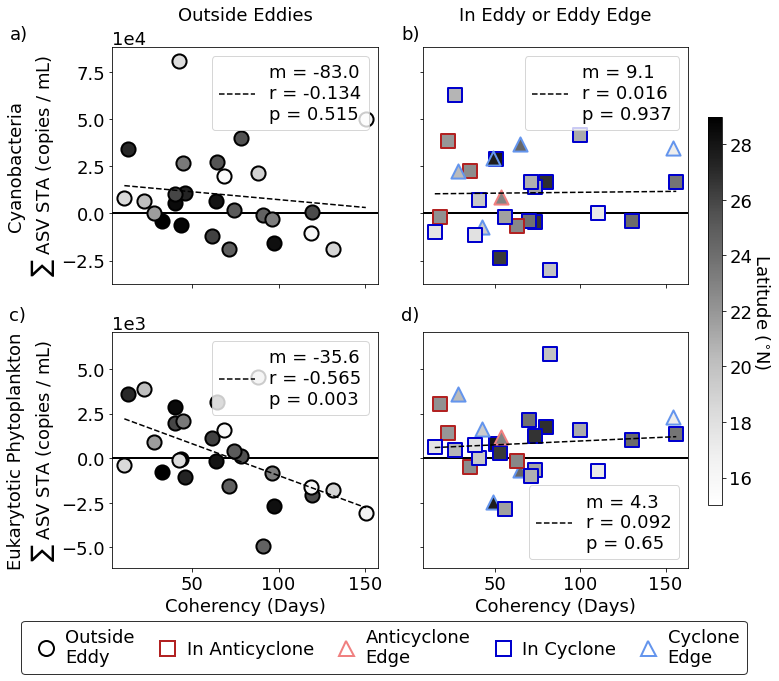

In [23]:
fig,ax = plt.subplots(2,2,figsize=(10,9)) # (width,height)
sc = sub_plot_param_v_coherence(ax[0,0],div_merged_df.Cyanobacteria,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                           include_cyc=False,include_anti=False,include_bg=True)
sub_plot_param_v_coherence(ax[0,1],div_merged_df.Cyanobacteria,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                           include_cyc=True,include_anti=True,include_bg=False)
sub_plot_param_v_coherence(ax[1,0],div_merged_df.Eukaryotes,div_merged_df.CMEMS_avg_coh,labels=False,colorbar='lat',
                           include_cyc=False,include_anti=False,include_bg=True)
sub_plot_param_v_coherence(ax[1,1],div_merged_df.Eukaryotes,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                            include_cyc=True,include_anti=True,include_bg=False)

for i, a in enumerate(ax.flat):
    a.axhline(0,c='k',linewidth=2,zorder=0)

ax[0,1].set_yticklabels([])
ax[1,1].set_yticklabels([])
ax[0,0].set_xticklabels([])
ax[0,1].set_xticklabels([])

ax[0,0].set_ylabel('Cyanobacteria\n$\sum$ ASV STA (copies / mL)')
ax[1,0].set_ylabel('Eukarytotic Phytoplankton\n$\sum$ ASV STA (copies / mL)')
ax[1,0].set_xlabel('Coherency (Days)')
ax[1,1].set_xlabel('Coherency (Days)')

ax[0,0].set_title('Outside Eddies\n')
ax[0,1].set_title('In Eddy or Eddy Edge\n')

ax[0,0].text(-56,9.25*(10**4),'a)')
ax[0,1].text(-5,9.25*(10**4),'b)')
ax[1,0].text(-56,7.75*(10**3),'c)')
ax[1,1].text(-5,7.75*(10**3),'d)')

# Colorbar
cb_ax = fig.add_axes([1, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cb_ax)
cb_ax.tick_params(axis='both', labelsize=fontsize)
cb_ax.set_ylabel('Latitude ($^{\circ}$N)',rotation=270,labelpad=20,fontsize=fontsize)    

### Legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Outside\nEddy', markeredgecolor='k', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='s', color='w', label='In Anticyclone', markeredgecolor='firebrick', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='^', color='w', label='Anticyclone\nEdge', markeredgecolor='lightcoral', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='s', color='w', label='In Cyclone', markeredgecolor='mediumblue', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='^', color='w', label='Cyclone\nEdge', markeredgecolor='cornflowerblue', markersize=15,markeredgewidth=2)]

legend = plt.legend(handles=legend_elements,
    loc="lower center", # "upper center" puts it below the line
    ncol=5,
    bbox_to_anchor=(0.55, -0.06),
    borderaxespad=0,
    bbox_transform=fig.transFigure,
    handletextpad=0.07,
    columnspacing=0.8)
legend.legendPatch.set_edgecolor("k")

############################################################

plt.tight_layout()
#plt.savefig(euk_paper_dir + 'figs/coh_vs_abundance_15km_edge_v3.pdf',dpi=350, bbox_inches='tight', format='pdf')

### Eukaryotes only

In [26]:
def bootstrap_linear_regression(bootstrap_df,sample_inds):
    
    coh_vals = div_merged_df.CMEMS_avg_coh[sample_inds]
    coh_vals_sorted = sorted(coh_vals) # used for regression output

    boot_fits, boot_slopes = [],[]
    boot_df_ind_subset = bootstrap_df[sample_inds].iloc[:,1:] # the 1 index ignore the sample name column

    for col in boot_df_ind_subset:
        boot_STA = boot_df_ind_subset[col]

        # FIT REGRESSION TO DATA
        slope, intercept, _, _, _ = spy.linregress(coh_vals, boot_STA)
        boot_slopes.append(slope)
        boot_fits.append([slope*i+intercept for i in coh_vals_sorted]) #regression y-vals
        
    return boot_fits, boot_slopes, coh_vals_sorted

/var/folders/3k/1t8n80h50719q9vxr497v8l40000gn/T/ipykernel_20193/1511455002.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


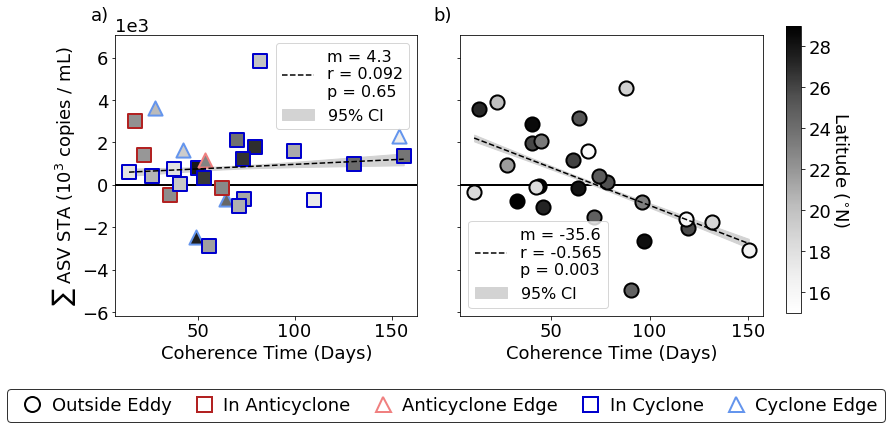

In [27]:
fig,ax = plt.subplots(1,2,figsize=(10.5,5.5)) # (width,height)

########################## REGRESSION CONFIDENCE INTERVALS #########################

euk_group_boot_sum = pd.read_csv(highcov_dir + 'bootstrapped_STAs/euk_bootstrapped_STA_sums.csv')

# In eddy 
eddy_inds = div_merged_df['eddy_color'].ne('k')
eddy_boot_fits, eddy_boot_slopes, eddy_x_vals = bootstrap_linear_regression(euk_group_boot_sum,eddy_inds)
eddy_fit_lower = np.quantile(eddy_boot_fits,0.025,axis=0)
eddy_fit_upper = np.quantile(eddy_boot_fits,0.975,axis=0)

ax[0].fill_between(eddy_x_vals,eddy_fit_lower,eddy_fit_upper,color='lightgray',label='$95\%$ CI')

# Outside eddy 
bg_inds = div_merged_df['eddy_color'].eq('k')
bg_boot_fits, bg_boot_slopes, bg_x_vals = bootstrap_linear_regression(euk_group_boot_sum,bg_inds)
bg_fit_lower = np.quantile(bg_boot_fits,0.025,axis=0)
bg_fit_upper = np.quantile(bg_boot_fits,0.975,axis=0)

ax[1].fill_between(bg_x_vals,bg_fit_lower,bg_fit_upper,color='lightgray',label='$95\%$ CI')

########################## SCATTER PLOTS #########################

sub_plot_param_v_coherence(ax[0],div_merged_df.Eukaryotes,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                            include_cyc=True,include_anti=True,include_bg=False)
sc = sub_plot_param_v_coherence(ax[1],div_merged_df.Eukaryotes,div_merged_df.CMEMS_avg_coh,labels=False,colorbar='lat',
                           include_cyc=False,include_anti=False,include_bg=True)

########################## AESTHETICS #########################

for i, a in enumerate(ax.flat):
    a.axhline(0,c='k',linewidth=2,zorder=0)

ax[1].set_yticklabels([])

ax[0].set_ylabel('$\sum$ ASV STA ($10^3$ copies / mL)')
ax[0].set_xlabel('Coherence Time (Days)')
ax[1].set_xlabel('Coherence Time (Days)')

#ax[0].set_title('Outside Eddies\n')
#ax[1].set_title('In Eddy or Eddy Edge\n')

ax[0].text(-5,7.75*(10**3),'a)')
ax[1].text(-10,7.75*(10**3),'b)')

# Colorbar
cb_ax = fig.add_axes([1, 0.175, 0.02, 0.725]) # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cb_ax)
cb_ax.tick_params(axis='both', labelsize=fontsize)
cb_ax.set_ylabel('Latitude ($^{\circ}$N)',rotation=270,labelpad=20,fontsize=fontsize)    

########################## LEGENDS #########################

ax[0].legend(fontsize=16)
ax[1].legend(fontsize=16)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='Outside Eddy', markeredgecolor='k', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='s', color='w', label='In Anticyclone', markeredgecolor='firebrick', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='^', color='w', label='Anticyclone Edge', markeredgecolor='lightcoral', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='s', color='w', label='In Cyclone', markeredgecolor='mediumblue', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='^', color='w', label='Cyclone Edge', markeredgecolor='cornflowerblue', markersize=15,markeredgewidth=2)]

legend = plt.legend(handles=legend_elements,
    loc="lower center", # "upper center" puts it below the line
    ncol=5,
    bbox_to_anchor=(0.55, -0.1),
    borderaxespad=0,
    bbox_transform=fig.transFigure,
    handletextpad=0.07,
    columnspacing=0.8)
legend.legendPatch.set_edgecolor("k")

############################################################

plt.tight_layout()
#plt.savefig(euk_paper_dir + 'figs/prelim/coh_vs_abundance_15km_edge_euk_only_v4.pdf',dpi=350, bbox_inches='tight', format='pdf')

In [28]:
print('Eddy slope CI:[%s,%s]'%(round(np.quantile(eddy_boot_slopes,0.025,axis=0),2),
                               round(np.quantile(eddy_boot_slopes,0.975,axis=0),2)))

Eddy slope CI:[1.27,7.26]


In [29]:
print('Outside slope CI:[%s,%s]'%(round(np.quantile(bg_boot_slopes,0.025,axis=0),2),
                               round(np.quantile(bg_boot_slopes,0.975,axis=0),2)))

Outside slope CI:[-38.01,-33.07]


### Cyanobacteria only

/var/folders/3k/1t8n80h50719q9vxr497v8l40000gn/T/ipykernel_20193/4081744581.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


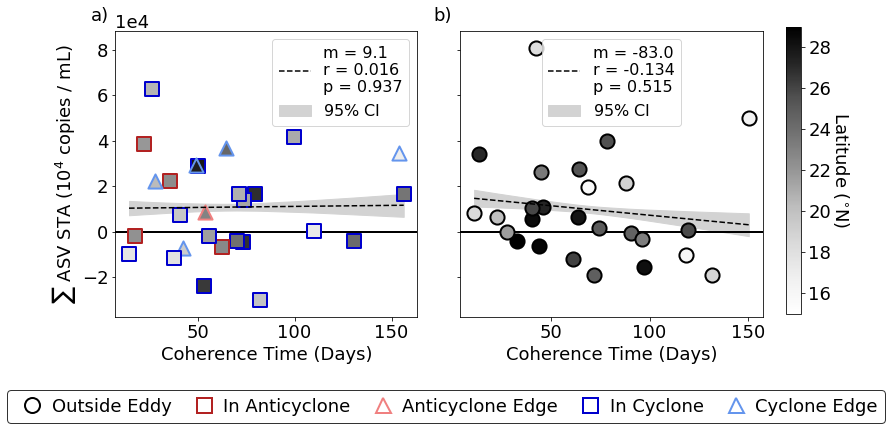

In [31]:
fig,ax = plt.subplots(1,2,figsize=(10.5,5.5)) # (width,height)


########################## REGRESSION CONFIDENCE INTERVALS #########################

cyan_group_boot_sum = pd.read_csv(highcov_dir + 'bootstrapped_STAs/cyan_bootstrapped_STA_sums.csv')

# In eddy 
eddy_inds = div_merged_df['eddy_color'].ne('k')
eddy_boot_fits, eddy_boot_slopes, eddy_x_vals = bootstrap_linear_regression(cyan_group_boot_sum,eddy_inds)
eddy_fit_lower = np.quantile(eddy_boot_fits,0.025,axis=0)
eddy_fit_upper = np.quantile(eddy_boot_fits,0.975,axis=0)

ax[0].fill_between(eddy_x_vals,eddy_fit_lower,eddy_fit_upper,zorder=0,color='lightgray',label='$95\%$ CI')

# Outside eddy 
bg_inds = div_merged_df['eddy_color'].eq('k')
bg_boot_fits, bg_boot_slopes, bg_x_vals = bootstrap_linear_regression(cyan_group_boot_sum,bg_inds)
bg_fit_lower = np.quantile(bg_boot_fits,0.025,axis=0)
bg_fit_upper = np.quantile(bg_boot_fits,0.975,axis=0)

ax[1].fill_between(bg_x_vals,bg_fit_lower,bg_fit_upper,zorder=0,color='lightgray',label='$95\%$ CI')

########################## SCATTER PLOTS #########################

sub_plot_param_v_coherence(ax[0],div_merged_df.Cyanobacteria,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                            include_cyc=True,include_anti=True,include_bg=False)
sc = sub_plot_param_v_coherence(ax[1],div_merged_df.Cyanobacteria,div_merged_df.CMEMS_avg_coh,labels=False,colorbar='lat',
                           include_cyc=False,include_anti=False,include_bg=True)

########################## AESTHETICS #########################

for i, a in enumerate(ax.flat):
    a.axhline(0,c='k',linewidth=2,zorder=0)

ax[1].set_yticklabels([])

ax[0].set_ylabel('$\sum$ ASV STA ($10^4$ copies / mL)')
ax[0].set_xlabel('Coherence Time (Days)')
ax[1].set_xlabel('Coherence Time (Days)')

#ax[0].set_title('Outside Eddies\n')
#ax[1].set_title('In Eddy or Eddy Edge\n')

ax[0].text(-5,9.25*(10**4),'a)')
ax[1].text(-10,9.25*(10**4),'b)')

# Colorbar
cb_ax = fig.add_axes([1, 0.175, 0.02, 0.725]) # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cb_ax)
cb_ax.tick_params(axis='both', labelsize=fontsize)
cb_ax.set_ylabel('Latitude ($^{\circ}$N)',rotation=270,labelpad=20,fontsize=fontsize)    

########################## LEGENDS #########################

ax[0].legend(fontsize=16)
ax[1].legend(fontsize=16)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='Outside Eddy', markeredgecolor='k', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='s', color='w', label='In Anticyclone', markeredgecolor='firebrick', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='^', color='w', label='Anticyclone Edge', markeredgecolor='lightcoral', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='s', color='w', label='In Cyclone', markeredgecolor='mediumblue', markersize=15,markeredgewidth=2),
                    Line2D([0], [0], marker='^', color='w', label='Cyclone Edge', markeredgecolor='cornflowerblue', markersize=15,markeredgewidth=2)]

legend = plt.legend(handles=legend_elements,
    loc="lower center", # "upper center" puts it below the line
    ncol=5,
    bbox_to_anchor=(0.55, -0.1),
    borderaxespad=0,
    bbox_transform=fig.transFigure,
    handletextpad=0.07,
    columnspacing=0.8)
legend.legendPatch.set_edgecolor("k")

############################################################

plt.tight_layout()
#plt.savefig(euk_paper_dir + 'figs/supp/coh_vs_abundance_15km_edge_cyan_only_v4.pdf',dpi=350, bbox_inches='tight', format='pdf')

In [32]:
print('Eddy slope CI:[%s,%s]'%(round(np.quantile(eddy_boot_slopes,0.025,axis=0),2),
                               round(np.quantile(eddy_boot_slopes,0.975,axis=0),2)))

Eddy slope CI:[-45.81,62.1]


In [33]:
print('Outside slope CI:[%s,%s]'%(round(np.quantile(bg_boot_slopes,0.025,axis=0),2),
                               round(np.quantile(bg_boot_slopes,0.975,axis=0),2)))

Outside slope CI:[-141.23,-25.96]


### Not seperated by eddy presence

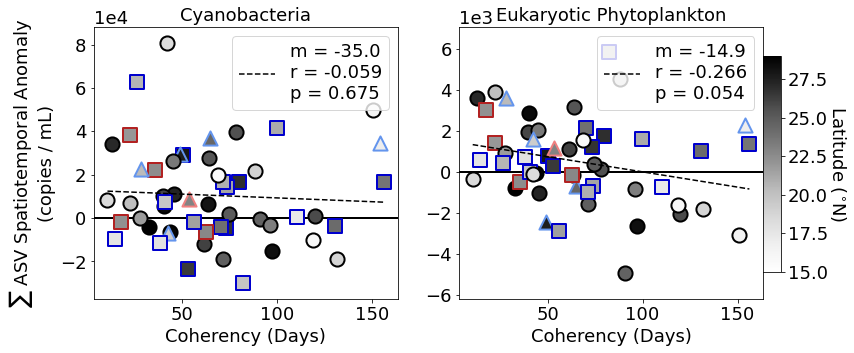

In [34]:
fig,ax = plt.subplots(1,2,figsize=(12,5)) # (width,height)

sc = sub_plot_param_v_coherence(ax[0],div_merged_df.Cyanobacteria,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                           include_cyc=True,include_anti=True,include_bg=True)
sub_plot_param_v_coherence(ax[1],div_merged_df.Eukaryotes,div_merged_df.CMEMS_avg_coh,colorbar='lat',
                           include_cyc=True,include_anti=True,include_bg=True)


for i, a in enumerate(ax.flat):
    a.axhline(0,c='k',linewidth=2,zorder=0)

ax[0].set_ylabel('$\sum$ ASV Spatiotemporal Anomaly\n(copies / mL)')
ax[0].set_title('Cyanobacteria')
ax[1].set_title('Eukaryotic Phytoplankton')
ax[0].set_xlabel('Coherency (Days)')
ax[1].set_xlabel('Coherency (Days)')

# Colorbar
cb_ax = fig.add_axes([0.9, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cb_ax)
cb_ax.tick_params(axis='both', labelsize=fontsize)
cb_ax.set_ylabel('Latitude ($^{\circ}$N)',rotation=270,labelpad=20,fontsize=fontsize)    

plt.show()

### Plot each euk group seperately

Color scheme matches `lat_diel_running_means_v3.ipynb` 

In [37]:
euk_color_dict = {'Prymnesiophyte':['#4056A1'],
             'Dinoflagellate':['#9269b5'],
             'Dictyochophyte':['#ad2713'],
             'Chrysophyte':['#376E6F'],
             'Unknown Eukaryote Chloroplast':['#808080'],
             'Pelagophyte':['#D79922'],
             'Diatom':['#E98074'],
             'Chlorophyte':['#88BDBC'],
             'Prasinodermophyte':['#899c75'],
             'Cryptophyte':['#e6ccb3']}

Abundant/significant groups (Fig S9a)

In [39]:
stat_table = [['slope','r','p']]

Text(-0.55, 1.12, 'a)')

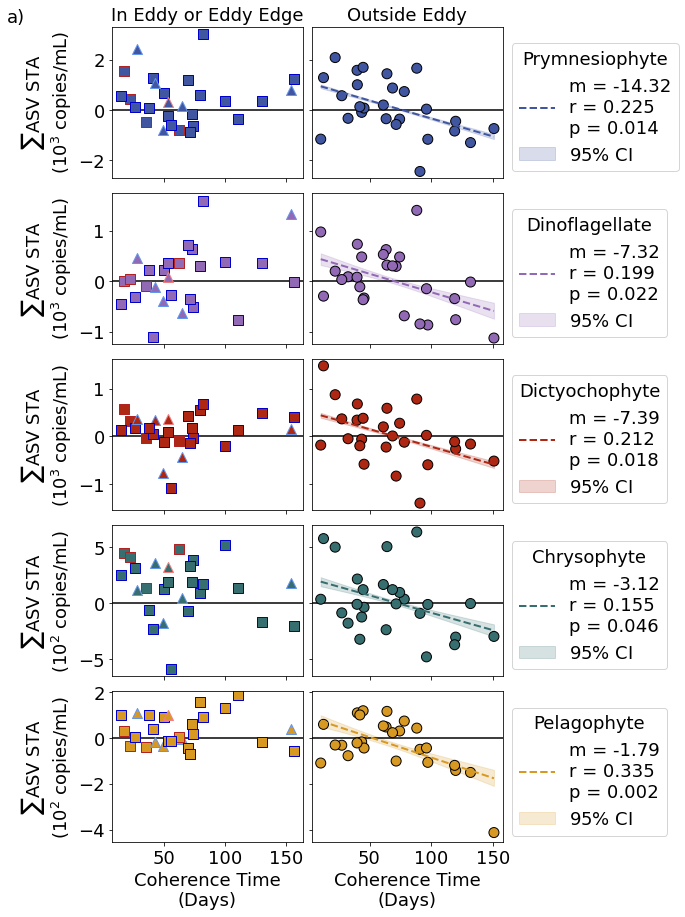

In [40]:
fig,ax = plt.subplots(5,2,figsize=(7,15)) # (width,height)
plt.subplots_adjust(wspace=0.05,hspace=0.1)

# Out of eddy inds / coherence
bg_inds = div_merged_df['eddy_color'].eq('k')
bg_x = div_merged_df.CMEMS_avg_coh[bg_inds]
bg_x_sorted = sorted(bg_x) # used for regression

# In eddy inds / coherence
eddy_inds = div_merged_df['eddy_color'].ne('k')
eddy_x = div_merged_df.CMEMS_avg_coh[eddy_inds]
eddy_x_sorted = sorted(eddy_x)

count = 0    
for col in ['Prymnesiophyte', 'Dinoflagellate', 'Dictyochophyte', 'Chrysophyte', 'Pelagophyte']:
    if col in ['Prymnesiophyte', 'Dinoflagellate', 'Dictyochophyte']:
        pwr = 3
    else:
        pwr = 2
        
    ########################## REGRESSION CONFIDENCE INTERVALS #########################

    group_boot_sum = pd.read_csv(highcov_dir + 'bootstrapped_STAs/%s_bootstrapped_STA_sums.csv'%(col))

    # Outside eddy 
    bg_boot_fits, bg_boot_slopes, bg_x_vals = bootstrap_linear_regression(group_boot_sum,bg_inds)
    bg_fit_lower = np.divide(np.quantile(bg_boot_fits,0.025,axis=0),10**pwr)
    bg_fit_upper = np.divide(np.quantile(bg_boot_fits,0.975,axis=0),10**pwr)

    ax[count,1].fill_between(bg_x_vals,bg_fit_lower,bg_fit_upper,zorder=0,
                             color=euk_color_dict[col][0],alpha=0.2,label='$95\%$ CI')
    
    ########################## SCATTER PLOTS #########################

    #### IN EDDY ####
    eddy_y = np.divide(div_merged_df[col][eddy_inds],10**pwr) # dividing by 10^pwr to have smaller numbers in plot

    # Fit lin. regression to data
    slope, intercept, r_value, p_value, std_err = spy.linregress(eddy_x, eddy_y)
    fit = [slope*i+intercept for i in eddy_x_sorted]

    edgecolors = list(div_merged_df[eddy_inds]['eddy_color'])
    for e in np.arange(0,len(edgecolors)):
        if (edgecolors[e] == 'mediumblue') or (edgecolors[e] == 'firebrick'):
            marker='s'
        elif (edgecolors[e] == 'cornflowerblue') or (edgecolors[e] == 'lightcoral'):
            marker='^'
        else:
            marker = 'circle'
        sc = ax[count,0].scatter(list(eddy_x)[e],list(eddy_y)[e],c=euk_color_dict[col][0],
                       edgecolor=edgecolors[e],marker=marker,s=100)
    #ax[count,0].plot(eddy_x_sorted,fit,linestyle='--',c=euk_color_dict[col][0],label='%s'%(col))

    #### NOT EDDY ####

    bg_y = np.divide(div_merged_df[col][bg_inds],10**pwr)

    # FIT REGRESSION TO DATA
    slope, intercept, r_value, p_value, std_err = spy.linregress(bg_x, bg_y)
    stat_table.append([col,round(slope*(10**pwr),2),round(r_value,3),round(p_value,3)]) # need to put slope back in correct units
    fit = [slope*i+intercept for i in bg_x_sorted]
    ax[count,1].scatter(bg_x,bg_y,c=euk_color_dict[col][0],s=100,
                        edgecolor=list(div_merged_df[bg_inds]['eddy_color']))
    ax[count,1].plot(bg_x_sorted,fit,linewidth=2,linestyle='--',c=euk_color_dict[col][0],
                     label='m = %s\nr = %s\np = %s'%(round(slope*(10**pwr),2),
                                                             round(r_value**2,3),
                                                             round(p_value,3)))
    ax[count,1].legend(title=col, bbox_to_anchor=(1,0.95))
    
    ########################## AESTHETICS #########################

    ax[count,0].set_ylabel('$\sum$ASV STA\n($10^%s$ copies/mL)'%(pwr))
    
    # Ylims
    ymin = np.min(list(eddy_y)+list(bg_y))-(np.abs(np.min(list(eddy_y)+list(bg_y)))/10)
    ymax = np.max(list(eddy_y)+list(bg_y))+(np.max(list(eddy_y)+list(bg_y))/10)
    ax[count,0].set_ylim([ymin,ymax])
    ax[count,1].set_ylim([ymin,ymax])
    ax[count,1].set_yticklabels([])
    
    ax[count,0].axhline(0,c='k',zorder=0)
    ax[count,1].axhline(0,c='k',zorder=0)
    
    if count != 4:
        ax[count,0].set_xticklabels([])
        ax[count,1].set_xticklabels([])
    
    count += 1

ax[0,0].set_title('In Eddy or Eddy Edge')
ax[0,1].set_title('Outside Eddy')
ax[4,0].set_xlabel('Coherence Time\n(Days)')
ax[4,1].set_xlabel('Coherence Time\n(Days)')

ax[0,0].text(-0.55, 1.12, 'a)',transform=ax[0,0].transAxes,va='top',ha='left')

#plt.savefig(euk_paper_dir + '/figs/supp/prelim/major_euk_group_STA_vs_coh_v4.pdf',dpi=350,bbox_inches='tight',format='pdf')

Minor groups (Fig S9b)

Text(-0.55, 1.12, 'b)')

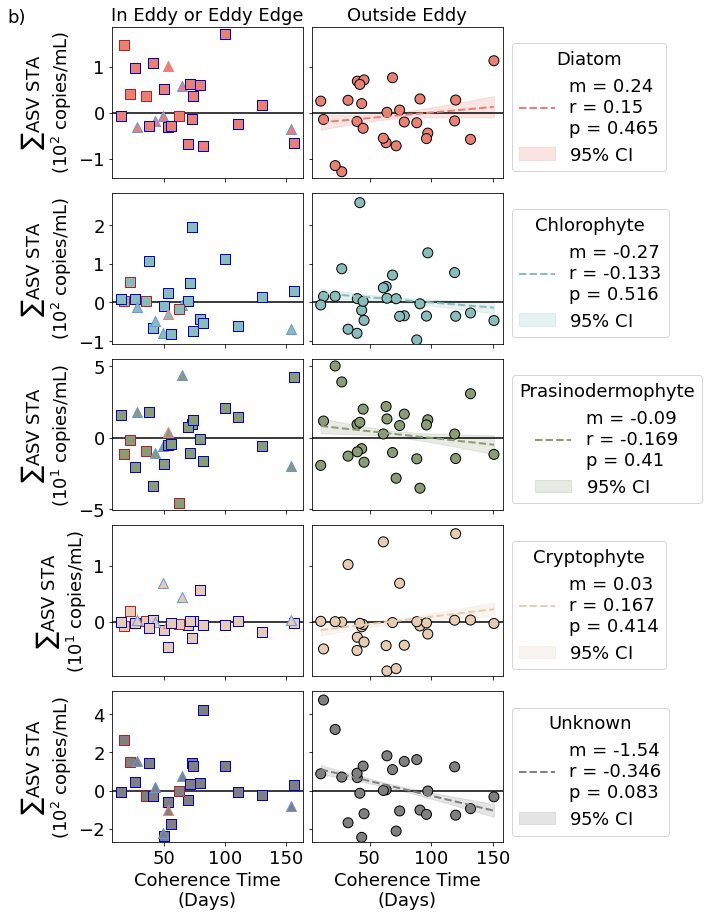

In [41]:
fig,ax = plt.subplots(5,2,figsize=(7,15)) # (width,height)
plt.subplots_adjust(wspace=0.05,hspace=0.1)

# Out of eddy inds / coherence
bg_inds = div_merged_df['eddy_color'].eq('k')
bg_x = div_merged_df.CMEMS_avg_coh[bg_inds]
bg_x_sorted = sorted(bg_x) # used for regression

# In eddy inds / coherence
eddy_inds = div_merged_df['eddy_color'].ne('k')
eddy_x = div_merged_df.CMEMS_avg_coh[eddy_inds]
eddy_x_sorted = sorted(eddy_x)

count = 0    
for col in ['Diatom', 'Chlorophyte','Prasinodermophyte', 'Cryptophyte','Unknown Eukaryote Chloroplast']:
    if col in ['Diatom', 'Chlorophyte','Unknown Eukaryote Chloroplast']:
        pwr = 2
    else:
        pwr = 1
        
    ########################## REGRESSION CONFIDENCE INTERVALS #########################

    group_boot_sum = pd.read_csv(highcov_dir + 'bootstrapped_STAs/%s_bootstrapped_STA_sums.csv'%(col))

    # Outside eddy 
    bg_boot_fits, bg_boot_slopes, bg_x_vals = bootstrap_linear_regression(group_boot_sum,bg_inds)
    bg_fit_lower = np.divide(np.quantile(bg_boot_fits,0.025,axis=0),10**pwr)
    bg_fit_upper = np.divide(np.quantile(bg_boot_fits,0.975,axis=0),10**pwr)

    ax[count,1].fill_between(bg_x_vals,bg_fit_lower,bg_fit_upper,zorder=0,
                             color=euk_color_dict[col][0],alpha=0.2,label='$95\%$ CI')
        
    ########################## SCATTER PLOTS #########################
    
    #### IN EDDY ####
    eddy_y = np.divide(div_merged_df[col][eddy_inds],10**pwr) 

    # Fit lin. regression to data
    slope, intercept, r_value, p_value, std_err = spy.linregress(eddy_x, eddy_y)
    fit = [slope*i+intercept for i in eddy_x_sorted]

    edgecolors = list(div_merged_df[eddy_inds]['eddy_color'])
    for e in np.arange(0,len(edgecolors)):
        if (edgecolors[e] == 'mediumblue') or (edgecolors[e] == 'firebrick'):
            marker='s'
        elif (edgecolors[e] == 'cornflowerblue') or (edgecolors[e] == 'lightcoral'):
            marker='^'
        else:
            marker = 'circle'
        sc = ax[count,0].scatter(list(eddy_x)[e],list(eddy_y)[e],c=euk_color_dict[col][0],
                       edgecolor=edgecolors[e],marker=marker,s=100)
    #ax[count,0].plot(eddy_x_sorted,fit,linestyle='--',c=euk_color_dict[col][0],label='%s'%(col))

    #### NOT EDDY ####

    bg_y = np.divide(div_merged_df[col][bg_inds],10**pwr)

    # FIT REGRESSION TO DATA
    slope, intercept, r_value, p_value, std_err = spy.linregress(bg_x, bg_y)
    stat_table.append([col,round(slope*(10**pwr),2),round(r_value,3),round(p_value,3)]) # need to put slope back in correct units
    fit = [slope*i+intercept for i in bg_x_sorted]
    ax[count,1].scatter(bg_x,bg_y,c=euk_color_dict[col][0],s=100,
                        edgecolor=list(div_merged_df[bg_inds]['eddy_color']))
    ax[count,1].plot(bg_x_sorted,fit,linewidth=2,linestyle='--',c=euk_color_dict[col][0],
                     label='m = %s\nr = %s\np = %s'%(round(slope*(10**pwr),2),round(r_value,3),round(p_value,3)))
    if col == 'Unknown Eukaryote Chloroplast':
        ax[count,1].legend(title='Unknown', bbox_to_anchor=(1,0.95))
    else:
        ax[count,1].legend(title=col, bbox_to_anchor=(1,0.95))
    
    ########################## AESTHETICS #########################
    
    ax[count,0].set_ylabel('$\sum$ASV STA\n($10^%s$ copies/mL)'%(pwr))
    
    # Ylims
    ymin = np.min(list(eddy_y)+list(bg_y))-(np.abs(np.min(list(eddy_y)+list(bg_y)))/10)
    ymax = np.max(list(eddy_y)+list(bg_y))+(np.max(list(eddy_y)+list(bg_y))/10)
    ax[count,0].set_ylim([ymin,ymax])
    ax[count,1].set_ylim([ymin,ymax])
    ax[count,1].set_yticklabels([])
    
    ax[count,0].axhline(0,c='k',zorder=0)
    ax[count,1].axhline(0,c='k',zorder=0)
    
    if count != 4:
        ax[count,0].set_xticklabels([])
        ax[count,1].set_xticklabels([])
    
    count += 1

ax[0,0].set_title('In Eddy or Eddy Edge')
ax[0,1].set_title('Outside Eddy')
ax[4,0].set_xlabel('Coherence Time\n(Days)')
ax[4,1].set_xlabel('Coherence Time\n(Days)')

ax[0,0].text(-0.55, 1.12, 'b)',transform=ax[0,0].transAxes,va='top',ha='left')

#plt.savefig(euk_paper_dir + '/figs/supp/prelim/minor_euk_group_STA_vs_coh_v4.pdf',dpi=350,bbox_inches='tight',format='pdf')

## Table S3

- Raw data Mean Abundance

For each niche (in eddy, eddy edge, and outside eddy):
- Mean STA with CI
- Std Dev STA

In [45]:
eddy_inds = div_merged_df['eddy_color'].ne('k')

# Seperate bg inds by coherence time 
out_coh_inds = div_merged_df['eddy_color'].eq('k') & (div_merged_df.CMEMS_avg_coh>=90)
out_mix_inds = div_merged_df['eddy_color'].eq('k') & (div_merged_df.CMEMS_avg_coh<90)

In [53]:
def bootstrap_mean(bootstrap_df,sample_inds):

    boot_means = []
    boot_df_ind_subset = bootstrap_df[sample_inds].iloc[:,1:] # the 1 index ignore the sample name column

    for col in boot_df_ind_subset:
        boot_STA = boot_df_ind_subset[col]
        boot_means.append(np.mean(boot_STA))

    boot_mean_lower = np.quantile(boot_means,0.025)
    boot_mean_upper = np.quantile(boot_means,0.975)
    
    return boot_mean_lower, boot_mean_upper

In [54]:
cyan_ASV_no_low_freq_df = pd.read_csv(highcov_dir + 'cyan_abs_ASV_abundance_IS_avg_station_avg_phytoplankon_filtered.csv',index_col=0)
euk_ASV_no_low_freq_df = pd.read_csv(highcov_dir + 'euk_abs_ASV_abundance_IS_avg_station_avg_phytoplankon_filtered.csv',index_col=0)

In [55]:
table_groups = [
 'Cyanobacteria',
 'Eukaryotes',
 'Prymnesiophyte', 
 'Dinoflagellate', 
 'Dictyochophyte', 
 'Chrysophyte', 
 'Pelagophyte',
 'Diatom', 
 'Chlorophyte',
 'Prasinodermophyte', 
 'Cryptophyte',
 'Unknown Eukaryote Chloroplast']

In [57]:
euk_grp_table = pd.read_csv(euk_paper_dir + 'euk_gp_table.csv',index_col=0)

In [58]:
avg_STA_columns = ['Abundance $\overline{X}$','Eddy & Edge STA $\overline{X}$', 'Eddy & Edge STA $\sigma$', 'Outside Mixed STA $\overline{X}$','Outside Mixed STA $\sigma$','Outside Coherent STA $\overline{X}$','Outside Coherent STA $\sigma$']
avg_STA_table = []

for grp in table_groups:
    
    temp_row = []
    
    # Bootstrap files have shortcut names for cyan and euks
    if grp == 'Cyanobacteria':
        boot_file_str = 'cyan'
        temp_row.append(round(np.mean(cyan_ASV_no_low_freq_df.sum(axis=1)),1))
    elif grp == 'Eukaryotes':
        boot_file_str = 'euk'
        temp_row.append(euk_grp_table.loc['All']['Mean (copies/mL)'])
    else:
        boot_file_str = grp
        temp_row.append(euk_grp_table.loc[grp]['Mean (copies/mL)'])

    for inds in [eddy_inds,out_mix_inds,out_coh_inds]:
        
        bootstrap_df = pd.read_csv(highcov_dir + 'bootstrapped_STAs/%s_bootstrapped_STA_sums.csv'%(boot_file_str))
        boot_mean_lower, boot_mean_upper = bootstrap_mean(bootstrap_df,inds)
        temp_row.append('%s, CI:[%s,%s]'%(round(np.mean(div_merged_df[grp].loc[inds]),1),
                                          round(boot_mean_lower,1), round(boot_mean_upper,1)))
        
        temp_row.append('%s'%(round(np.std(div_merged_df[grp].loc[inds]),1)))

    avg_STA_table.append(temp_row)
    
avg_STA_df = pd.DataFrame(avg_STA_table,columns=avg_STA_columns,index=table_groups)
avg_STA_df

,Abundance $\overline{X}$,Eddy & Edge STA $\overline{X}$,Eddy & Edge STA $\sigma$,Outside Mixed STA $\overline{X}$,Outside Mixed STA $\sigma$,Outside Coherent STA $\overline{X}$,Outside Coherent STA $\sigma$
Cyanobacteria,223682.7,"10839.6, CI:[9319.5,12298.0]",21237.4,"13610.5, CI:[11575.2,15704.1]",21774.5,"345.6, CI:[-3974.1,4585.4]",21318.7
Eukaryotes,20453.1,"813.8, CI:[732.2,881.4]",1753.4,"1175.2, CI:[1076.8,1270.1]",1748.6,"-2418.3, CI:[-2605.2,-2225.3]",1231.9
Prymnesiophyte,7582.6,"416.0, CI:[372.3,452.9]",943.7,"548.0, CI:[503.6,591.4]",894.0,"-988.2, CI:[-1075.6,-894.4]",724.0
Dinoflagellate,4220.3,"80.0, CI:[26.5,129.9]",580.0,"252.4, CI:[182.6,324.5]",488.9,"-583.9, CI:[-720.2,-445.6]",385.5
Dictyochophyte,3907.0,"98.6, CI:[72.8,120.9]",389.7,"195.8, CI:[162.4,227.5]",530.6,"-433.6, CI:[-499.8,-369.6]",445.1
Chrysophyte,2369.3,"137.8, CI:[119.4,155.4]",255.6,"105.4, CI:[81.8,127.3]",268.5,"-223.5, CI:[-267.8,-178.9]",173.7
Pelagophyte,602.4,"34.8, CI:[24.8,43.8]",69.1,"18.9, CI:[5.2,33.5]",70.4,"-145.9, CI:[-175.7,-114.8]",115.8
Diatom,307.4,"20.5, CI:[14.0,26.3]",63.4,"-9.8, CI:[-19.6,0.4]",57.9,"-0.7, CI:[-22.7,22.5]",57.5
Chlorophyte,207.3,"-1.5, CI:[-6.3,3.7]",63.6,"8.7, CI:[0.7,16.0]",75.1,"7.9, CI:[-5.0,20.7]",62.5
Prasinodermophyte,50.9,"-0.5, CI:[-2.8,1.6]",19.9,"4.3, CI:[1.4,7.3]",19.8,"-1.0, CI:[-6.2,4.3]",19.8


In [84]:
#avg_STA_df.to_csv(euk_paper_dir + 'avg_STA_by_group_v4.csv')

## Exponential Decay of Abundance

The solution for $\frac{1}{C}\frac{DC}{DT} = \mu$ is $C(t) = N_0 e^{\mu t}$. Here we simulate the temporal transformation of a population entering a coherent water mass, given the STAs of outside-eddy populations.

First, we create an artificial dataset of abundance by adding the outside-eddy STAs to the average abundance. Then, we fit an exponential to derive the e-folding time. 

In [59]:
phyto_group_abund_df = pd.read_csv(highcov_dir + 'group_level_abs_ASV_abundance_IS_avg_station_avg_phytoplankon_filtered.csv',index_col=0)
phyto_group_abund_df.head()

,Chlorophyte,Chrysophyte,Cryptophyte,Diatom,Diazotroph,Dictyochophyte,Dinoflagellate,Pelagophyte,Picocyanobacteria,Prasinodermophyte,Prymnesiophyte,Unknown Eukaryote Chloroplast
sample_id,,,,,,,,,,,,
16,110.048054,1240.167125,16.999746,275.804371,15.966064,3544.225935,3205.385190,574.908487,156265.737383,3.659004,5865.537110,854.617607
17,141.221169,1478.917838,0.000000,289.653305,17.011887,3779.370939,3828.104849,642.488469,167018.718590,8.158246,6470.224888,784.684933
18,165.653141,1798.307663,0.000000,345.657441,31.017010,4464.900185,4319.723707,743.954263,176434.258828,4.325177,7516.011736,1064.202615
19,339.989462,1315.965788,0.000000,203.377400,0.000000,2163.227938,2178.996038,465.571158,156331.380406,32.351655,4201.516817,810.499092
20,212.412926,1285.449856,0.000000,194.655637,78.427659,2924.505816,4194.065450,623.309179,171497.237077,46.232985,5788.625662,979.633590


NOTE: Pearson's r is used to express the relationship between two variables, while R^2 is used to evaluate the quality of the fit. 

Using custom R2 code here because sklearn not working on home computer; same result as with sklearn r2score.

In [60]:
def calculate_R2(y_true, y_pred):
    """
    y_true: Observed values
    y_pred: Predicted values from the model
    """
    # Mean of the observed values 
    y_mean = np.mean(y_true) 
    
    # Sum of squared differences between observed values and their mean
    ss_tot = np.sum((y_true - y_mean) ** 2)
    
    # Sum of squared differences between observed values and predicted values
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    return 1 - (ss_res / ss_tot)

In [61]:
def exponential_decay(t, N0, tau):
    return N0 * np.exp(-t / tau) 

In [62]:
def bootstrap_exp_regression(bootstrap_df,group_avg_abundance,sample_inds):
    
    coh_vals = div_merged_df.CMEMS_avg_coh[sample_inds]
    coh_vals_sorted = sorted(coh_vals) # used for regression output

    boot_fits, boot_half_lives, boot_R2s = [],[],[]
    boot_df_ind_subset = bootstrap_df[sample_inds].iloc[:,1:] # the 1 index ignore the sample name column

    for col in boot_df_ind_subset:
        y = boot_df_ind_subset[col] + group_avg_abundance

        # Fit Model
        params, param_cov = curve_fit(exponential_decay, coh_vals, y, p0=[max(y),100])
        N0_fit, tau_fit = params[0],params[1]
        
        # Get half life
        boot_half_lives.append(round(tau_fit*np.log(2)))
        
        # Modeled y vals
        y_pred = exponential_decay(coh_vals, N0_fit, tau_fit) # for R2 calc
        y_pred_extended = exponential_decay(np.arange(0,200), N0_fit, tau_fit) # for plotting
        boot_fits.append(y_pred_extended)

        # Calculate R^2 of Model Fit
        boot_R2s.append(calculate_R2(y,y_pred)) # (y_data,y_predicted)     
        
    return boot_fits, boot_half_lives, boot_R2s

Text(0.5, 0, 'Coherence Time (Days)')

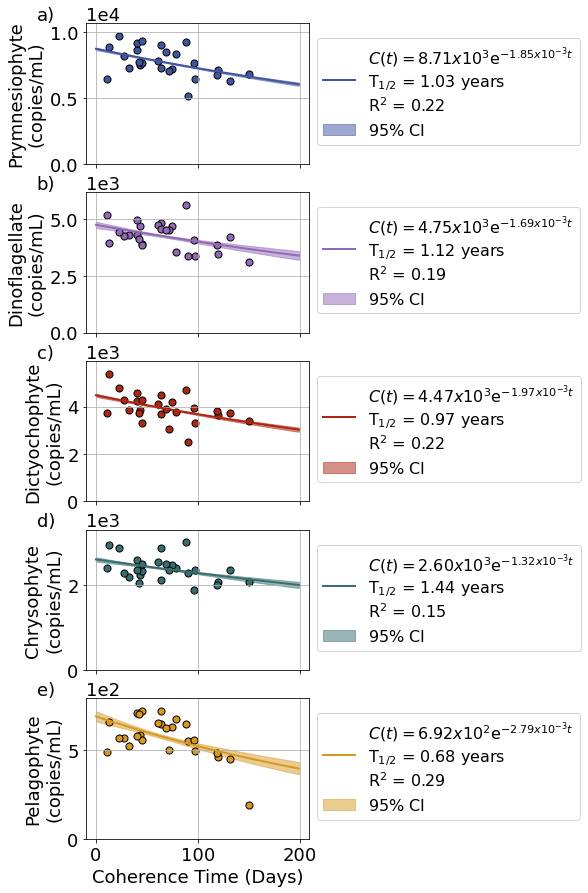

In [63]:
fig,ax = plt.subplots(5,1,figsize=(4,15)) # (width,height)

# Out of eddy inds / coherence
bg_inds = div_merged_df['eddy_color'].eq('k')
bg_x = div_merged_df.CMEMS_avg_coh[bg_inds]
bg_x_sorted = sorted(bg_x) # used for regression

panel_labels = ['a)','b)','c)','d)','e)']

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return "%sx10^{%s}"%(a,b)

count = 0    
for col in ['Prymnesiophyte', 'Dinoflagellate', 'Dictyochophyte', 'Chrysophyte', 'Pelagophyte']:

    # Scatter Data
    x = np.array(div_merged_df.CMEMS_avg_coh[bg_inds]) # time (days)
    group_avg_abundance = euk_grp_table['Mean (copies/mL)'][col]
    y = group_avg_abundance + np.array(div_merged_df[col][bg_inds]) # mean abundance + STA 
    ax[count].scatter(x,y,c=euk_color_dict[col][0],s=50,edgecolor='k')

    
    ######## CI #########
    group_boot_sum = pd.read_csv(highcov_dir + 'bootstrapped_STAs/%s_bootstrapped_STA_sums.csv'%(col))

    boot_fits, boot_half_lives, boot_R2s = bootstrap_exp_regression(group_boot_sum,
                                                                    group_avg_abundance,
                                                                    bg_inds)
    lower_fit = np.quantile(boot_fits,0.025,axis=0)
    upper_fit = np.quantile(boot_fits,0.975,axis=0)
    
    x_extended = np.arange(0,200)
    ax[count].fill_between(x_extended,lower_fit,upper_fit,color=euk_color_dict[col][0],alpha=0.5,zorder=0,label='$95\%$ CI')
    
    
    ######## Fit Model to Scat Data #######
    params, param_cov = curve_fit(exponential_decay, x, y, p0=[max(y),100])
    N0_fit, tau_fit = params[0],params[1]
    half_life = round(tau_fit*np.log(2))
    y_pred = exponential_decay(x, N0_fit, tau_fit)
    
    # Calculate R^2 of Model Fit
    r2 = calculate_R2(y,y_pred) # (y_data,y_predicted)
    
    x_extended = np.arange(0,200) # How many days to plot?
    ax[count].plot(x_extended,exponential_decay(x_extended, N0_fit, tau_fit),
                     c=euk_color_dict[col][0],linewidth=2,
                     label="$C(t)=%s$e$^{-%st}$\nT$_{1/2}$ = %s years\nR$^2$ = %s"%(sci_notation(N0_fit),
                                                                      sci_notation(1/tau_fit),
                                                                      round(half_life/365,2),
                                                                      round(r2,2)))
    
    
    # TEST: compare with linear fit
    #slope, intercept, r_value, p_value, std_err = spy.linregress(x, y)
    #fit = [slope*i+intercept for i in bg_x_sorted]
    #ax[count].plot(sorted(x),fit,linewidth=2,linestyle='--',c='k',label='m = %s'%(round(slope,2)))
    
    
    ax[count].set_ylim([0,max(y)+0.1*max(y)])    
    ax[count].grid()
    ax[count].legend(bbox_to_anchor=(1,0.95),fontsize=16)
    
    #### PARAMS ####
    ax[count].text(-0.22, 1.12, panel_labels[count],transform=ax[count].transAxes,va='top',ha='left')
    ax[count].set_ylabel('%s\n(copies/mL)'%(col))
    ax[count].ticklabel_format(axis='y', style='sci', scilimits=(0,0))  
    if count != 4:
        ax[count].set_xticklabels([])
    
    count += 1

ax[4].set_xlabel('Coherence Time (Days)')

#plt.savefig(euk_paper_dir + '/figs/major_euk_group_exp_model_v3.pdf',dpi=350,bbox_inches='tight',format='pdf')

## Eddy Enhancement Stats

Which groups are the most enhanced in each eddy?

In [64]:
eddy_dict = {849094:'Shrutie',
             799833:'Josh',
             847844:'Cathy',
             845344:'Koko',
             844202:'Dean',
             831329:'Zinka',
             823188:'Sharon'}

In [65]:
euk_groups = [
 'Prymnesiophyte', 
 'Dinoflagellate', 
 'Dictyochophyte', 
 'Chrysophyte', 
 'Pelagophyte',
 'Diatom', 
 'Chlorophyte',
 'Prasinodermophyte', 
 'Cryptophyte',
 'Unknown Eukaryote Chloroplast']

In [66]:
eddy_group_sum_dict = {} # eddy: group sum
for eddy in np.unique(div_merged_df['in_cyc']):
    if eddy != 0:
        print('**************** ' + eddy_dict[eddy] +' ****************')
        in_eddy_group_sums = div_merged_df[euk_groups].loc[div_merged_df[div_merged_df['in_cyc']==eddy].index].sum(axis=0)
        eddy_group_sum_dict[eddy_dict[eddy]] = in_eddy_group_sums
        print(in_eddy_group_sums.sort_values(ascending=False))
        
for eddy in np.unique(div_merged_df['in_anti']):
    if eddy != 0:
        print('**************** ' + eddy_dict[eddy] +' ****************')
        in_eddy_group_sums = div_merged_df[euk_groups].loc[div_merged_df[div_merged_df['in_anti']==eddy].index].sum(axis=0)
        eddy_group_sum_dict[eddy_dict[eddy]] = in_eddy_group_sums
        print(in_eddy_group_sums.sort_values(ascending=False))

**************** Sharon ****************
Chrysophyte                       969.919192
Diatom                            337.848603
Unknown Eukaryote Chloroplast     165.429149
Pelagophyte                        71.028949
Chlorophyte                        14.458600
Cryptophyte                        -0.823341
Prasinodermophyte                  -3.006340
Dinoflagellate                  -1054.520274
Dictyochophyte                  -1293.329717
Prymnesiophyte                  -1698.086991
dtype: float64
**************** Zinka ****************
Dinoflagellate                   1311.669920
Dictyochophyte                    818.747822
Chrysophyte                       462.019316
Pelagophyte                       207.559181
Chlorophyte                       175.837088
Prymnesiophyte                    174.880407
Unknown Eukaryote Chloroplast     125.547201
Diatom                             17.912982
Prasinodermophyte                   2.972898
Cryptophyte                        -1.789643
dtyp

### Diatom STAs

Sample 51: Cyc Sharon

Sample 46: Anti Josh

In [67]:
div_merged_df['Diatom'].sort_values(ascending=False)

34    169.957396
29    147.252671
50    112.915353
40    107.006613
26    100.421065
36     96.998729
52     76.037414
7      71.362933
2      68.528971
35     63.362129
45     61.497774
9      60.361280
20     58.601908
5      51.753779
30     41.714804
28     36.181964
33     35.912397
19     29.972427
14     27.675279
0      27.143210
44     25.298176
1      20.008678
21     16.896929
17      5.875242
16      1.105125
47     -6.048488
6      -6.303673
27     -7.648735
10    -12.439931
8     -14.438369
51    -17.622269
41    -17.713465
13    -18.926111
15    -19.924430
42    -21.617928
48    -24.554673
32    -28.382049
46    -28.817058
11    -30.008366
37    -31.524165
24    -33.583617
49    -35.837324
3     -44.062083
12    -55.144876
25    -56.006842
43    -57.650588
23    -64.641336
4     -64.909874
22    -68.608084
18    -71.631094
39    -71.680036
38   -114.542893
31   -127.782245
Name: Diatom, dtype: float64